## Code Implementation

In [1]:
import numpy as np
from PIL import Image

In [2]:
def message_to_binary(message):
    binary_message = ""
    for char in message:
        binary_message += format(ord(char), '08b')
    binary_message += format(0, '08b') 
    return binary_message

def binary_to_message(binary_data):
    message = ""
    for i in range(0, len(binary_data), 8):
        byte = binary_data[i:i+8]
        if len(byte) < 8: break
        char_code = int(byte, 2)
        if char_code == 0: break
        message += chr(char_code)
    return message

def find_sobel_edges(red_channel, threshold=30):
    """
    Applies a Sobel filter exclusively to the Red channel matrix.
    Returns a list of coordinate tuples (x, y) where edges are detected.
    """
    height, width = red_channel.shape
    edge_coordinates = []
    
    sobel_x = np.array([[-1, 0, 1], 
                        [-2, 0, 2], 
                        [-1, 0, 1]], dtype=float)
                        
    sobel_y = np.array([[-1, -2, -1], 
                        [ 0,  0,  0], 
                        [ 1,  2,  1]], dtype=float)
    
    for y in range(1, height - 1):
        for x in range(1, width - 1):
            neighborhood = red_channel[y-1:y+2, x-1:x+2]
            gx = np.sum(neighborhood * sobel_x)
            gy = np.sum(neighborhood * sobel_y)
            
            magnitude = np.sqrt(gx**2 + gy**2)
            
            if magnitude > threshold:
                edge_coordinates.append((x, y))
                
    return edge_coordinates

def encode_edge_lsb(image_path, secret_message, output_path, threshold=30):
    """Embeds data only into the Green and Blue LSBs of detected edge pixels."""
    img = Image.open(image_path).convert('RGB')
    pixels = img.load()
    
    img_array = np.array(img, dtype=float)
    red_channel = img_array[:, :, 0]
    
    binary_msg = message_to_binary(secret_message)
    msg_index = 0
    msg_len = len(binary_msg)
    
    edge_pixels = find_sobel_edges(red_channel, threshold)
    
    if msg_len > len(edge_pixels) * 2:
        raise ValueError(f"Message too long! Need {msg_len} bits, but this image configuration only has {len(edge_pixels) * 2} available edge slots.")
        
    for x, y in edge_pixels:
        if msg_index >= msg_len:
            break
            
        r, g, b = pixels[x, y]
        
        # Modify Green Channel LSB
        if msg_index < msg_len:
            g = (g & ~1) | int(binary_msg[msg_index])
            msg_index += 1
            
        # Modify Blue Channel LSB
        if msg_index < msg_len:
            b = (b & ~1) | int(binary_msg[msg_index])
            msg_index += 1
            
        # Write modified variables back into memory (leaving 'r' intact)
        pixels[x, y] = (r, g, b)
        
    img.save(output_path, "PNG")
    print(f"Success! Data hidden inside {len(edge_pixels)} Sobel edge coordinates.")

def decode_sobel_edge_lsb(image_path, threshold=30):
    """Extracts data from Green and Blue LSBs"""
    img = Image.open(image_path).convert('RGB')
    pixels = img.load()
    
    img_array = np.array(img, dtype=float)
    red_channel = img_array[:, :, 0]
    
    # Calculate the exact same edge map since the Red channel was not modified
    edge_pixels = find_sobel_edges(red_channel, threshold)
    
    binary_data = ""
    
    for x, y in edge_pixels:
        r, g, b = pixels[x, y]
        binary_data += str(g & 1)
        binary_data += str(b & 1)
        
        if len(binary_data) % 8 == 0:
            last_byte = binary_data[-8:]
            if int(last_byte, 2) == 0:
                return binary_to_message(binary_data)
                
    return binary_to_message(binary_data)

# --- Example Usage ---
if __name__ == "__main__":
    secret_payload = "Sobel Edge-Based Steganography works seamlessly with channel isolation!"
    EDGE_THRESHOLD = 35
    
    # Encode phase
    encode_sobel_edge_lsb("input_image.jpg", secret_payload, "edge_stego.png", threshold=EDGE_THRESHOLD)
    
    # Decode phase
    recovered_text = decode_sobel_edge_lsb("edge_stego.png", threshold=EDGE_THRESHOLD)
    print(f"\nDecoded Message:\n-> {recovered_text}")

Success! Data hidden inside 108748 Sobel edge coordinates.

Decoded Message:
-> Sobel Edge-Based Steganography works seamlessly with channel isolation!


## Image Plotting

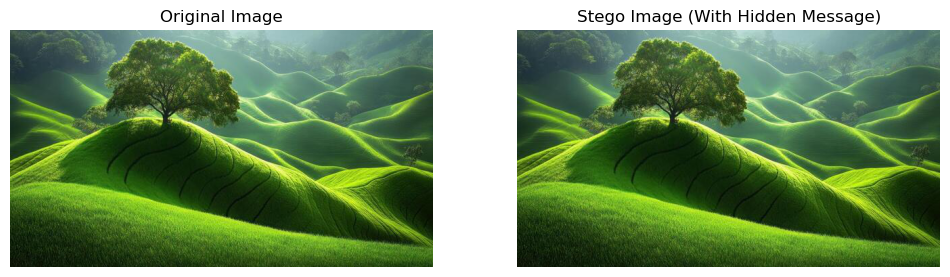

In [3]:
import matplotlib.pyplot as plt

# Load both images
original = Image.open("input_image.jpg")
stego = Image.open("edge_stego.png")

# Plot them side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(original)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(stego)
axes[1].set_title("Stego Image (With Hidden Message)")
axes[1].axis('off')

plt.show()